# Pears 3

In [12]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import matplotlib.pyplot as plt

In [13]:
def create_volume_bars(ask_file, bid_file, vol_threshold=1000):
    """Helper function to convert raw Bid/Ask parquets into Volume Bars."""
    
    # Load and sort
    df_ask = pd.read_parquet(ask_file).sort_values('datetime')
    df_bid = pd.read_parquet(bid_file).sort_values('datetime')
    
    # Rename columns
    df_ask = df_ask.rename(columns={'price': 'ask_price', 'volume': 'ask_volume'})
    df_bid = df_bid.rename(columns={'price': 'bid_price', 'volume': 'bid_volume'})
    
    # Asynchronous merge
    df_ticks = pd.merge_asof(
        df_ask[['datetime', 'ask_price', 'ask_volume']],
        df_bid[['datetime', 'bid_price', 'bid_volume']],
        on='datetime',
        direction='backward'
    ).dropna()
    
    # Calculations
    df_ticks['mid_price'] = (df_ticks['bid_price'] + df_ticks['ask_price']) / 2
    df_ticks['total_volume'] = df_ticks['bid_volume'] + df_ticks['ask_volume']
    df_ticks['cum_vol'] = df_ticks['total_volume'].cumsum()
    
    # Bar Generation
    df_ticks['bar_id'] = (df_ticks['cum_vol'] // vol_threshold).astype(int)
    
    bars = df_ticks.groupby('bar_id').agg(
        timestamp=('datetime', 'last'),
        open=('mid_price', 'first'),
        high=('mid_price', 'max'),
        low=('mid_price', 'min'),
        close=('mid_price', 'last'),
        volume=('total_volume', 'sum')
    ).set_index('timestamp')
    
    return bars


In [14]:
def prepare_pairs_dataframe(ask_A, bid_A, ask_B, bid_B, vol_threshold=1000):
    """Main pipeline: Processes two assets and aligns them into one DataFrame."""
    print("Processing Asset A...")
    bars_A = create_volume_bars(ask_A, bid_A, vol_threshold)
    
    print("Processing Asset B...")
    bars_B = create_volume_bars(ask_B, bid_B, vol_threshold)
    
    print("Aligning timelines...")
    # Align Asset B's prices to Asset A's volume bar timeline
    df_pairs = pd.merge_asof(
        bars_A[['close']].rename(columns={'close': 'Asset_A'}),
        bars_B[['close']].rename(columns={'close': 'Asset_B'}),
        left_index=True,
        right_index=True,
        direction='backward'
    ).dropna()
    
    print(f"Success! Final aligned pairs dataset has {len(df_pairs)} rows.")
    return df_pairs

In [15]:
file_a_ask = "../data/processed/eurnok_dukascopy_ask_202601.parquet"
file_a_bid = "../data/processed/eurnok_dukascopy_bid_202601.parquet"

file_b_ask = "../data/processed/eursek_dukascopy_ask_202601.parquet"
file_b_bid = "../data/processed/eursek_dukascopy_bid_202601.parquet"

# Generate the master dataframe
df_pairs = prepare_pairs_dataframe(file_a_ask, file_a_bid, file_b_ask, file_b_bid, vol_threshold=1000)

print(df_pairs.head(3))

Processing Asset A...


Processing Asset B...
Aligning timelines...
Success! Final aligned pairs dataset has 6878 rows.
                                    Asset_A    Asset_B
timestamp                                             
2025-12-31 20:45:04.820000+00:00  11.843680  10.821385
2025-12-31 20:59:04.422000+00:00  11.845155  10.821385
2025-12-31 21:08:09.415000+00:00  11.842805  10.820090


In [16]:
def calculate_dynamic_spread(df, window=100):
    """Calculates a rolling hedge ratio and extracts the stationary spread."""
    print(f"Calculating Rolling Beta (Window: {window} bars)...")
    
    # We predict Asset A using Asset B. Add a constant for the intercept.
    exog = sm.add_constant(df['Asset_B'])
    rols = RollingOLS(df['Asset_A'], exog, window=window)
    rolling_res = rols.fit()
    
    # Extract the beta (the coefficient for Asset_B)
    df['beta'] = rolling_res.params['Asset_B']
    
    # Calculate the Spread: A - (Beta * B)
    df['spread'] = df['Asset_A'] - (df['beta'] * df['Asset_B'])
    
    # Drop the initial NaN rows where the 100-bar window was filling up
    df_clean = df.dropna()
    
    print(f"Success! Spread calculated. {len(df_clean)} rows ready for modeling.")
    return df_clean

In [17]:
df_clean = calculate_dynamic_spread(df_pairs, window=100)

print(df_clean[['Asset_A', 'Asset_B', 'beta', 'spread']].head(3))

Calculating Rolling Beta (Window: 100 bars)...
Success! Spread calculated. 6779 rows ready for modeling.
                                    Asset_A    Asset_B      beta    spread
timestamp                                                                 
2026-01-02 10:16:11.430000+00:00  11.810210  10.820965  0.422357  7.239900
2026-01-02 10:23:20.627000+00:00  11.811285  10.820965  0.376499  7.737206
2026-01-02 10:31:58.830000+00:00  11.819845  10.821865  0.338007  8.161977


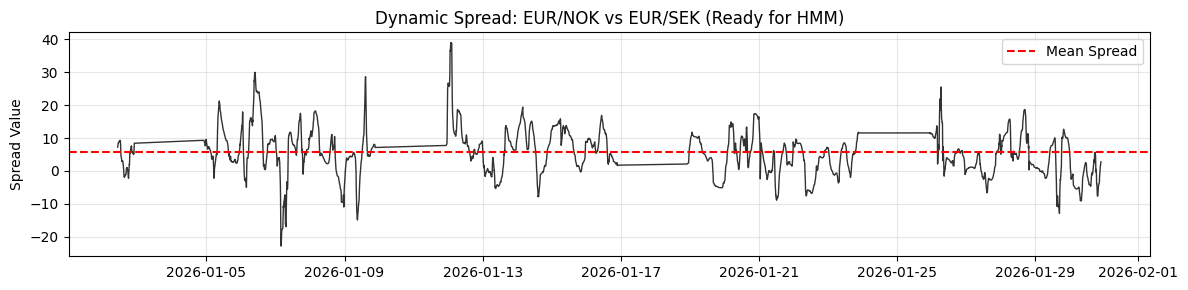

In [18]:
plt.figure(figsize=(12, 3))
plt.plot(df_clean.index, df_clean['spread'], color='black', linewidth=1, alpha=0.8)
plt.axhline(df_clean['spread'].mean(), color='red', linestyle='--', label='Mean Spread')
plt.title("Dynamic Spread: EUR/NOK vs EUR/SEK (Ready for HMM)")
plt.ylabel("Spread Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()